# Differential expression analysis


You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).


We would now like to understand exactly the difference between the expression in our groups of mice. 
Which pipeline would you use for this?

I´ll run the differential analisys between the genes of different mice groups using the nf-core/differentialabundace pipeline 

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

In [8]:
%%bash
head -n1 data/salmon.merged.gene_counts.tsv | tr '\t' '\n' | tail -n +3 > samples.txt

echo "sample,Condition" > samplesheet.csv
while read s; do
  cond=$(echo "$s" | sed -E 's/_[0-9]+$//')
  echo "$s,$cond" >> samplesheet.csv
done < samples.txt

cat samplesheet.csv

sample,Condition
Sham_oxy_1,Sham_oxy
Sham_oxy_2,Sham_oxy
Sham_oxy_3,Sham_oxy
Sham_oxy_4,Sham_oxy
Sham_Sal_1,Sham_Sal
Sham_Sal_2,Sham_Sal
Sham_Sal_3,Sham_Sal
Sham_Sal_4,Sham_Sal
SNI_oxy_1,SNI_oxy
SNI_oxy_2,SNI_oxy
SNI_oxy_3,SNI_oxy
SNI_oxy_4,SNI_oxy
SNI_Sal_1,SNI_Sal
SNI_Sal_2,SNI_Sal
SNI_Sal_3,SNI_Sal
SNI_Sal_4,SNI_Sal


Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [9]:
!nextflow run nf-core/differentialabundance \
  -profile docker \
  --input samplesheet.csv \
  --matrix data/salmon.merged.gene_counts.tsv \
  --transcript_length_matrix data/salmon.merged.gene_lengths.tsv \
  --contrasts data/contrasts.csv \
  --outdir results \
  -resume


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [fabulous_laplace] revision: 5cb5f9858f [master]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  input                       : samplesheet.csv
  contrasts                   : data/contrasts.csv
  outdir                      : results

[base] Abundance values
  matrix                      : data/salmon.merged.gene_counts.tsv

[preprocessing] Filtering
  filtering_min_abundance     : 1
  filte

Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.

-profile docker: containers<br>
-r 2.0.0: fixed version<br>
--input: sample sheet<br>
--matrix: counts<br>
--contrasts: comparisons<br>
--outdir: outputs<br>
-resume: cache


What were the outputs of the pipeline?

pipeline_info/ — software versions, execution trace<br>
other/ — intermediate/auxiliary files<br>
plots/ — QC, exploratory (PCA, dendrogram), differential volcano plots<br>
report/ — HTML report + zip bundle<br>
shinyngs_app/ — interactive Shiny app<br>
tables/ — normalised/VST matrices, DESeq2 results, filtered DEG tables

In [10]:
#!TODO

In [11]:
import pandas as pd
for f in ["results/tables/differential/contrasts/condition_control_treated_test_study.deseq2.results_filtered.tsv",
          "results/tables/differential/contrasts/condition_control_treated_study.deseq2.results_filtered.tsv"]:
    df = pd.read_csv(f, sep="\t")
    print(f, len(df))

results/tables/differential/contrasts/condition_control_treated_test_study.deseq2.results_filtered.tsv 7
results/tables/differential/contrasts/condition_control_treated_study.deseq2.results_filtered.tsv 18


Would you exclude any samples? If yes, which and why?

Yes, possibly SNI_Sal_2 and SNI_Sal_4. They have much lower counts across genes, suggesting low library size/outliers. I would confirm with PCA/dendrogram and exclude only if they clearly separate from the other SNI_Sal samples.

How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?

Sham_oxy vs Sham_Sal: 7<br>
SNI_oxy vs SNI_Sal: 18<br>

Paper: DEGs in 3 separate regions (NAc, mPFC, VTA): hundreds per region<br>
Ours: lower numbers<br>
The paper uses a full factorial design with an interaction term; we only have pairwise contrasts

The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.

NAc: nucleus accumbens — reward, motivation, addiction.<br>
mPFC: medial prefrontal cortex — executive function, emotion, pain regulation.<br>
VTA: ventral tegmental area — dopamine, reward, motivation.

Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?

Partially. The paper reports key region-specific genes and supplementary DEG tables per region, but not full gene lists, these require supplementary data.

Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?

No. They need functional enrichment, network analysis, and validation. DEG lists alone, without functional context, have limited utility.

Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentionned.

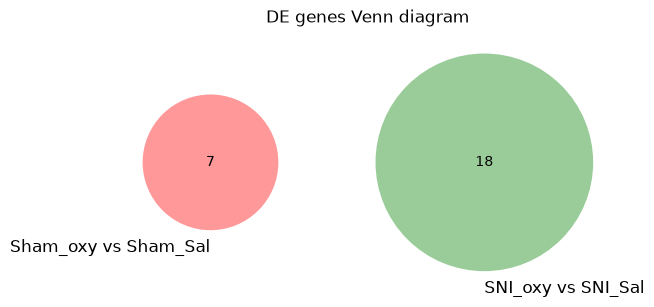

In [12]:
import pandas as pd
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

c1 = pd.read_csv("results/tables/differential/contrasts/condition_control_treated_test_study.deseq2.results_filtered.tsv", sep="\t")
c2 = pd.read_csv("results/tables/differential/contrasts/condition_control_treated_study.deseq2.results_filtered.tsv", sep="\t")

venn2([set(c1.gene_id), set(c2.gene_id)],
      set_labels=("Sham_oxy vs Sham_Sal", "SNI_oxy vs SNI_Sal"))
plt.title("DE genes Venn diagram")
plt.savefig("venn_contrasts.png", dpi=300)
plt.show()